# ScribeCheck — Setup & Data Exploration

**Author:** Shivanshu Ade  
**Project:** Handwritten Text Evaluation System Using OCR  
**Course:** Deep Learning - Semester Project, Spring 2026  

---

This notebook demonstrates:
1. Environment verification - all dependencies installed and importable
2. Dataset loading - IAM Handwriting Database via HuggingFace
3. Data exploration - summary statistics, sample visualizations, and distributions
4. TrOCR inference - running the pre-trained model on sample images
5. OCR evaluation - CER and WER metrics
6. Similarity scoring - hybrid metric demo

---
## 1. Environment Verification

Verify that all required packages are installed and check hardware availability.

In [3]:
!pip install transformers
!pip install jiwer
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [jiwer]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s  0:00:00


In [4]:
import sys
print(f"Python version: {sys.version}\n")

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

import transformers
print(f"Transformers: {transformers.__version__}")

import datasets
print(f"Datasets: {datasets.__version__}")

import cv2
print(f"OpenCV: {cv2.__version__}")

import numpy as np
import pandas as pd
import matplotlib
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

import PIL
print(f"Pillow: {PIL.__version__}")

from jiwer import wer, cer
print(f"jiwer: imported successfully")

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print(f"NLTK: {nltk.__version__} (punkt data downloaded)")

print("\n--- All dependencies verified successfully! ---")

Python version: 3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]

PyTorch: 2.5.1
CUDA available: False
Transformers: 5.5.0
Datasets: 4.6.1
OpenCV: 4.13.0
NumPy: 2.2.6
Pandas: 2.3.3
Matplotlib: 3.10.8
Pillow: 12.1.0
jiwer: imported successfully
NLTK: 3.9.4 (punkt data downloaded)

--- All dependencies verified successfully! ---


---
## 2. Dataset Loading — IAM Handwriting Database

The IAM Handwriting Database contains handwritten English text samples from over 650 different writers. Each sample is a line-level image paired with its ground truth transcription. We load it directly from HuggingFace Datasets, so no manual download or registration is needed.

In [6]:
from datasets import load_dataset

print("Loading IAM Handwriting Dataset from HuggingFace...")
iam_dataset = load_dataset("Teklia/IAM-line", split="train")

print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(iam_dataset)}")
print(f"Features: {iam_dataset.features}")
print(f"\nSample entry:")
sample = iam_dataset[0]
print(f"  Keys: {list(sample.keys())}")
print(f"  Text: '{sample['text']}'")
print(f"  Image size: {sample['image'].size}")
print(f"  Image mode: {sample['image'].mode}")

Loading IAM Handwriting Dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]


Dataset loaded successfully!
Total samples: 6482
Features: {'image': Image(mode=None, decode=True), 'text': Value('string')}

Sample entry:
  Keys: ['image', 'text']
  Text: 'put down a resolution on the subject'
  Image size: (2467, 128)
  Image mode: L


---
## 3. Data Exploration

### 3.1 Sample Images
Visualize a selection of handwriting samples alongside their ground truth labels to understand the diversity and variation in the dataset.

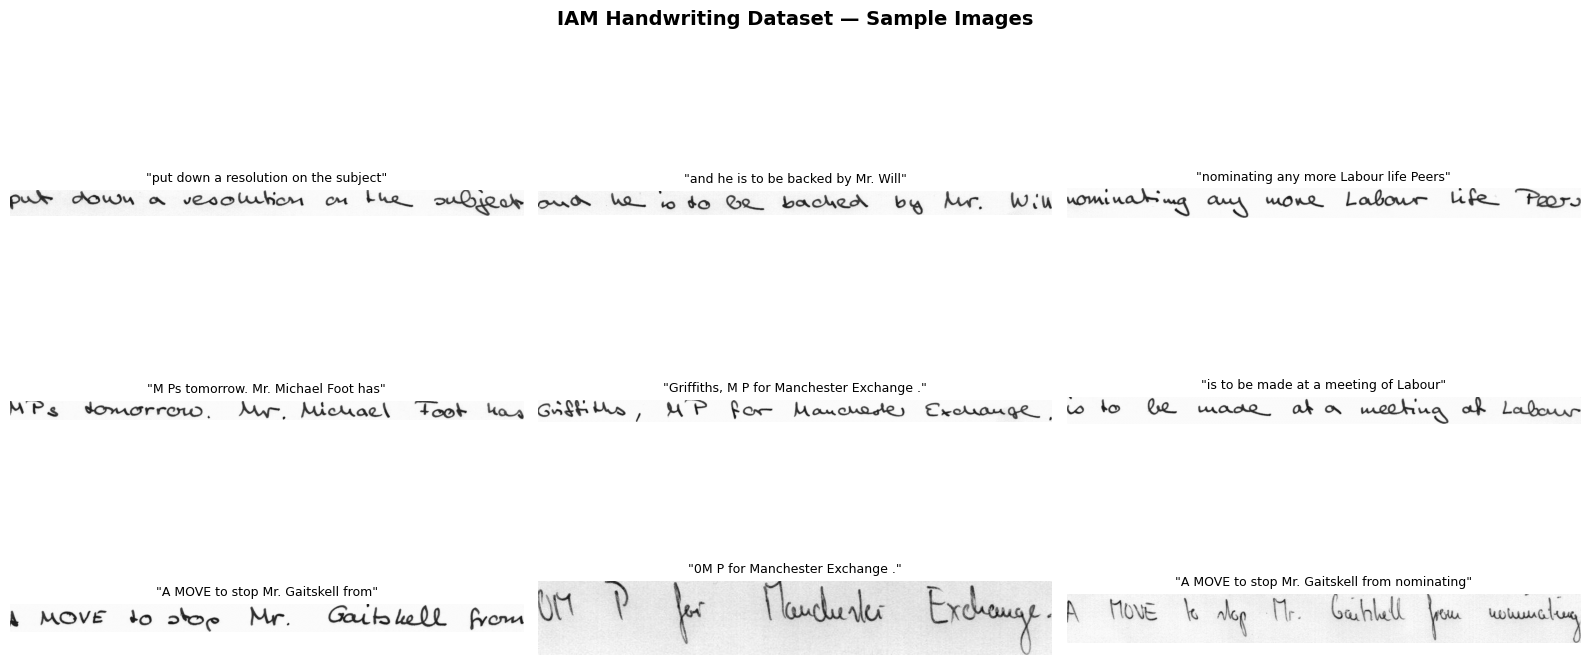

Saved: results/sample_images.png


In [8]:
import matplotlib.pyplot as plt
import os

os.makedirs('../results', exist_ok=True)

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
fig.suptitle("IAM Handwriting Dataset — Sample Images", fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    sample = iam_dataset[idx]
    ax.imshow(sample['image'], cmap='gray')
    label = sample['text']
    display_label = label if len(label) <= 50 else label[:47] + '...'
    ax.set_title(f'"{display_label}"', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/sample_images.png")

### 3.2 Text Length Statistics
Analyze the distribution of text lengths (characters and words) across the dataset.

In [9]:
# Compute text statistics across the full dataset
text_lengths = [len(iam_dataset[i]['text']) for i in range(len(iam_dataset))]
word_counts = [len(iam_dataset[i]['text'].split()) for i in range(len(iam_dataset))]

print("=" * 50)
print("TEXT LENGTH SUMMARY STATISTICS")
print("=" * 50)
print(f"Total samples:        {len(iam_dataset)}")
print(f"\nCharacter counts:")
print(f"  Mean:   {np.mean(text_lengths):.1f}")
print(f"  Median: {np.median(text_lengths):.0f}")
print(f"  Std:    {np.std(text_lengths):.1f}")
print(f"  Min:    {min(text_lengths)}")
print(f"  Max:    {max(text_lengths)}")
print(f"\nWord counts:")
print(f"  Mean:   {np.mean(word_counts):.1f}")
print(f"  Median: {np.median(word_counts):.0f}")
print(f"  Std:    {np.std(word_counts):.1f}")
print(f"  Min:    {min(word_counts)}")
print(f"  Max:    {max(word_counts)}")

TEXT LENGTH SUMMARY STATISTICS
Total samples:        6482

Character counts:
  Mean:   43.4
  Median: 43
  Std:    10.2
  Min:    1
  Max:    80

Word counts:
  Mean:   8.5
  Median: 8
  Std:    2.4
  Min:    1
  Max:    19


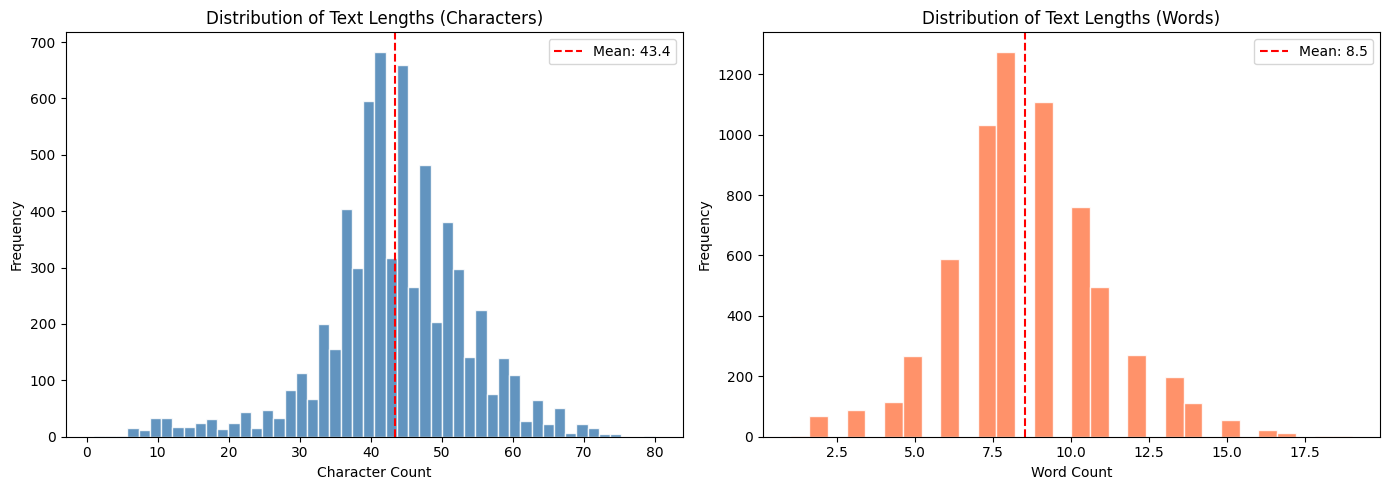

Saved: results/text_length_distributions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(text_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Lengths (Characters)')
axes[0].axvline(np.mean(text_lengths), color='red', linestyle='--',
                label=f'Mean: {np.mean(text_lengths):.1f}')
axes[0].legend()

axes[1].hist(word_counts, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Text Lengths (Words)')
axes[1].axvline(np.mean(word_counts), color='red', linestyle='--',
                label=f'Mean: {np.mean(word_counts):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/text_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/text_length_distributions.png")

### 3.3 Image Dimension Analysis
Check the variation in image sizes to understand preprocessing needs.

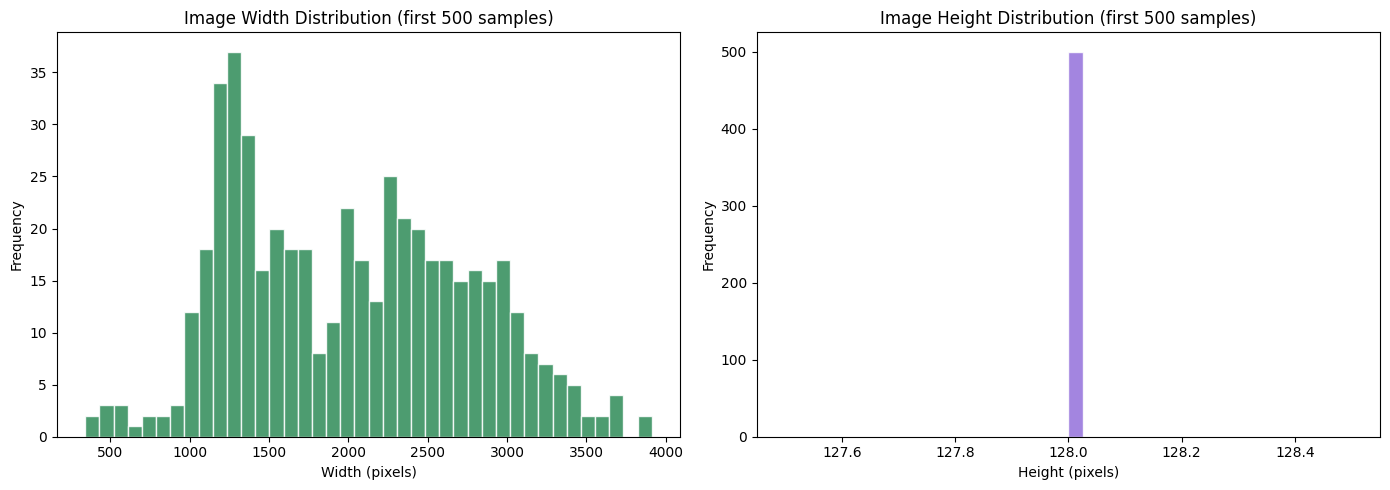


Image dimensions (first 500 samples):
  Width  — Mean: 2015px, Range: [341, 3913]
  Height — Mean: 128px, Range: [128, 128]


In [11]:
num_inspect = min(500, len(iam_dataset))
widths = [iam_dataset[i]['image'].size[0] for i in range(num_inspect)]
heights = [iam_dataset[i]['image'].size[1] for i in range(num_inspect)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Image Width Distribution (first {num_inspect} samples)')

axes[1].hist(heights, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Image Height Distribution (first {num_inspect} samples)')

plt.tight_layout()
plt.savefig('../results/image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImage dimensions (first {num_inspect} samples):")
print(f"  Width  — Mean: {np.mean(widths):.0f}px, Range: [{min(widths)}, {max(widths)}]")
print(f"  Height — Mean: {np.mean(heights):.0f}px, Range: [{min(heights)}, {max(heights)}]")